# CREAM Noisy-Graph Analysis

Standalone CREAM on one expert graph — baseline for mCREAM ensemble comparison.

- **Black dashed** = CREAM on ground truth DAG (upper bound)
- **Colored lines** = CREAM on noisy expert graphs

**Noise:** deletion / addition / reversal × low / medium / high  
**Datasets:** Complete_Concept_FMNIST, CelebA


In [1]:
import pandas as pd, numpy as np, ast
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Same palette as mCREAM ensemble analysis
ACTION_COLOR = {
    'deletion': '#B55D60',   # muted red
    'addition': '#5B8E7D',   # muted green/teal
    'reversal': '#5F7EA8'    # muted blue
}

EXPERT_COLORS = [
    '#4E79A7',  # blue
    '#A05A5A',  # muted red
    '#6B8E6B',  # muted green
    '#B08D57',  # muted gold
    '#7A6FA3'   # muted purple
]
EXPERT_MARKERS = ['o','s','^','D','v']
LEVEL_ALPHA    = {'low':0.45,'medium':0.70,'high':1.0}

EXPERIMENTS_ROOT = Path('/home/dani00003/mCREAM/experiments')
DATASETS   = ['Complete_Concept_FMNIST','CelebA']
ACTIONS    = ['deletion','addition','reversal']
LEVELS     = ['low','medium','high']
N_EXPERTS  = 5
MODEL_MAP  = {
    'Complete_Concept_FMNIST': ('Standard_FashionMNIST','CREAM_best_cfmnist'),
    'CelebA':                  ('Standard_CelebA',      'CREAM_best_celeba'),
}
print(f'Root exists: {EXPERIMENTS_ROOT.exists()}')


Root exists: True


## 1. Load Results


In [2]:
def load_noisy(root):
    rows = []
    for ds in DATASETS:
        model = MODEL_MAP[ds][0]
        md = root/ds/'train_cbm'/model/'cream_noisy_ensemble'/'last_metrics'
        if not md.exists(): print(f'  [SKIP] {md}'); continue
        for f in sorted(md.glob('cream_noisy_*.csv')):
            p = f.stem.split('_')
            try: act=p[2]; lv=p[3]; ex=int(p[4].replace('expert',''))
            except: continue
            df = pd.read_csv(f)
            df['dataset']=ds; df['action']=act; df['noise_level']=lv; df['expert']=ex
            rows.append(df)
    if not rows: print('No results found'); return pd.DataFrame()
    df = pd.concat(rows, ignore_index=True)
    print(f'Loaded {len(df)} rows')
    return df

def load_gt(root):
    rows, irows = [], []
    for ds,(model,exp) in MODEL_MAP.items():
        md = root/ds/'train_cbm'/model/'CREAM'/'last_metrics'
        if not md.exists(): print(f'  [SKIP] GT: {md}'); continue
        for f in sorted(md.glob('*.csv')):
            df = pd.read_csv(f)
            if len(df)==0: continue
            df['dataset']=ds; rows.append(df)
            if 'intervention_results' in df.columns:
                raw = df['intervention_results'].iloc[0]
                if isinstance(raw, str):
                    for e in ast.literal_eval(raw):
                        irows.append({'dataset':ds,
                            'num_interventions':e['num_interventions'],
                            'test_task_accuracy':e['metrics']['test_task_accuracy'],
                            'group_interventions':e.get('group_interventions',False)})
    gt_s = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    gt_i = pd.DataFrame(irows) if irows else pd.DataFrame()
    if len(gt_s)>0:
        for d in gt_s['dataset'].unique():
            r = gt_s[gt_s['dataset']==d].iloc[0]
            print(f'  GT {d}: acc={r.get("test_task_accuracy",float("nan")):.4f}  CCI={r.get("CCI","N/A")}')
    return gt_s, gt_i

def parse_interv(noisy_df):
    rows = []
    if 'intervention_results' not in noisy_df.columns: return pd.DataFrame()
    for _,row in noisy_df.iterrows():
        raw = row['intervention_results']
        if not isinstance(raw, str): continue
        for e in ast.literal_eval(raw):
            rows.append({'dataset':row['dataset'],'action':row['action'],
                'noise_level':row['noise_level'],'expert':row['expert'],
                'num_interventions':e['num_interventions'],
                'test_task_accuracy':e['metrics']['test_task_accuracy'],
                'group_interventions':e.get('group_interventions',False)})
    df = pd.DataFrame(rows)
    print(f'Parsed {len(df)} intervention rows')
    return df

noisy_df         = load_noisy(EXPERIMENTS_ROOT)
gt_df, gt_interv = load_gt(EXPERIMENTS_ROOT)
interv_df        = parse_interv(noisy_df)


  [SKIP] /home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/cream_noisy_ensemble/last_metrics
Loaded 45 rows
  GT Complete_Concept_FMNIST: acc=0.9231  CCI=0.9309468643999848
  GT CelebA: acc=0.8163  CCI=1.0
Parsed 720 intervention rows


## 2. Summary Table


In [3]:
if len(noisy_df)==0: print('No data')
else:
    KEY = ['test_task_accuracy','test_concept_accuracy','CCI',
           'PFI_concept_importance','PFI_side_importance']
    av  = [c for c in KEY if c in noisy_df.columns]
    means = noisy_df.groupby(['dataset','action','noise_level','expert'])[av].mean()
    stds  = noisy_df.groupby(['dataset','action','noise_level','expert'])[av].std()
    sm = pd.DataFrame(index=means.index)
    for c in av:
        sm[c] = means[c].map('{:.4f}'.format) + ' +/- ' + stds[c].map('{:.4f}'.format)
    if len(gt_df)>0:
        print('--- Ground Truth CREAM ---')
        for d in DATASETS:
            sub = gt_df[gt_df['dataset']==d]
            if sub.empty: continue
            r = sub.iloc[0]
            for c in av:
                if c in r.index: print(f'  {d:35s} {c:30s} {r[c]:.4f}')
    for d in DATASETS:
        if d not in means.index.get_level_values('dataset'): continue
        print(f'\n--- {d} ---')
        display(sm.xs(d, level='dataset'))


--- Ground Truth CREAM ---
  Complete_Concept_FMNIST             test_task_accuracy             0.9231
  Complete_Concept_FMNIST             test_concept_accuracy          0.9806
  Complete_Concept_FMNIST             CCI                            0.9309
  Complete_Concept_FMNIST             PFI_concept_importance         0.7002
  Complete_Concept_FMNIST             PFI_side_importance            0.0356
  CelebA                              test_task_accuracy             0.8163
  CelebA                              test_concept_accuracy          0.8105
  CelebA                              CCI                            1.0000
  CelebA                              PFI_concept_importance         0.3165
  CelebA                              PFI_side_importance            -0.0000

--- Complete_Concept_FMNIST ---


test_task_accuracy test_concept_accuracy  \
action   noise_level expert                                            
addition high        0          0.9232 +/- nan        0.9726 +/- nan   
                     1          0.9267 +/- nan        0.9732 +/- nan   
                     2          0.9265 +/- nan        0.9732 +/- nan   
                     3          0.9241 +/- nan        0.9727 +/- nan   
                     4          0.9237 +/- nan        0.9812 +/- nan   
         low         0          0.9256 +/- nan        0.9730 +/- nan   
                     1          0.9251 +/- nan        0.9729 +/- nan   
                     2          0.9240 +/- nan        0.9812 +/- nan   
                     3          0.9253 +/- nan        0.9727 +/- nan   
                     4          0.9244 +/- nan        0.9817 +/- nan   
         medium      0          0.9250 +/- nan        0.9728 +/- nan   
                     1          0.9248 +/- nan        0.9729 +/- nan   
                     2          0.9245 +/- nan        0.9727 +/- nan   
                     3          0.9257 +/- nan        0.9730 +/- nan   
                     4          0.9239 +/- nan        0.9812 +/- nan   
deletion high        0          0.9220 +/- nan        0.9668 +/- nan   
                     1          0.9222 +/- nan        0.9653 +/- nan   
                     2          0.8219 +/- nan        0.9170 +/- nan   
                     3          0.8264 +/- nan        0.9335 +/- nan   
                     4          0.9199 +/- nan        0.9356 +/- nan   
         low         0          0.9231 +/- nan        0.9380 +/- nan   
                     1          0.9243 +/- nan        0.9804 +/- nan   
                     2          0.8253 +/- nan        0.9726 +/- nan   
                     3          0.9229 +/- nan        0.9786 +/- nan   
                     4          0.9203 +/- nan        0.9548 +/- nan   
         medium      0          0.9211 +/- nan        0.9628 +/- nan   
                     1          0.9197 +/- nan        0.9330 +/- nan   
                     2          0.9190 +/- nan        0.9504 +/- nan   
                     3          0.9206 +/- nan        0.9551 +/- nan   
                     4          0.9197 +/- nan        0.9277 +/- nan   
reversal high        0          0.9220 +/- nan        0.9670 +/- nan   
                     1          0.9155 +/- nan        0.9654 +/- nan   
                     2          0.8241 +/- nan        0.9154 +/- nan   
                     3          0.8262 +/- nan        0.9331 +/- nan   
                     4          0.9230 +/- nan        0.9359 +/- nan   
         low         0          0.9228 +/- nan        0.9387 +/- nan   
                     1          0.9244 +/- nan        0.9802 +/- nan   
                     2          0.8261 +/- nan        0.9726 +/- nan   
                     3          0.9225 +/- nan        0.9784 +/- nan   
                     4          0.9209 +/- nan        0.9548 +/- nan   
         medium      0          0.9224 +/- nan        0.9627 +/- nan   
                     1          0.9211 +/- nan        0.9325 +/- nan   
                     2          0.9186 +/- nan        0.9491 +/- nan   
                     3          0.9203 +/- nan        0.9553 +/- nan   
                     4          0.9221 +/- nan        0.9276 +/- nan   

                                         CCI PFI_concept_importance  \
action   noise_level expert                                           
addition high        0        0.9983 +/- nan         0.8041 +/- nan   
                     1        0.9980 +/- nan         0.8059 +/- nan   
                     2        0.9989 +/- nan         0.8046 +/- nan   
                     3        0.9986 +/- nan         0.7950 +/- nan   
                     4        0.9986 +/- nan         0.7979 +/- nan   
         low         0        0.9944 +/- nan         0.7901 +/- nan   
                     1        0.9942 +/- nan         0.7912 +/- nan   
    

## 3. Task & Concept Accuracy per Expert


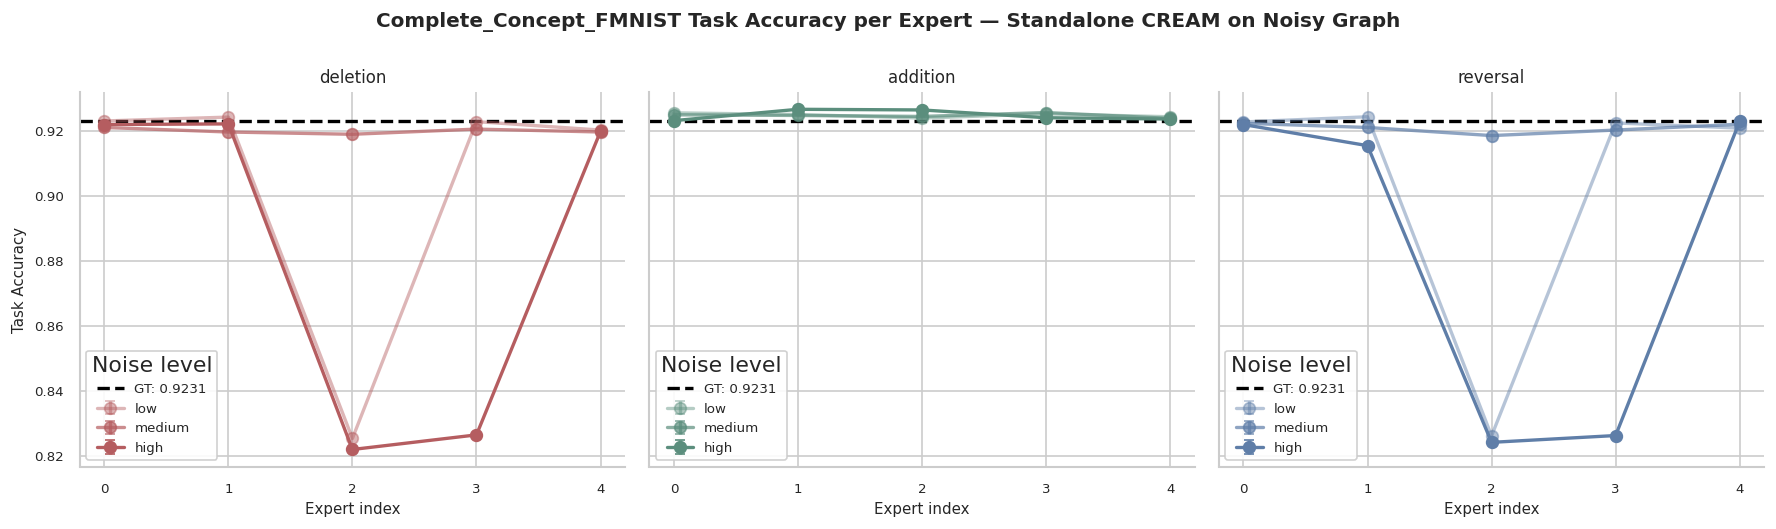

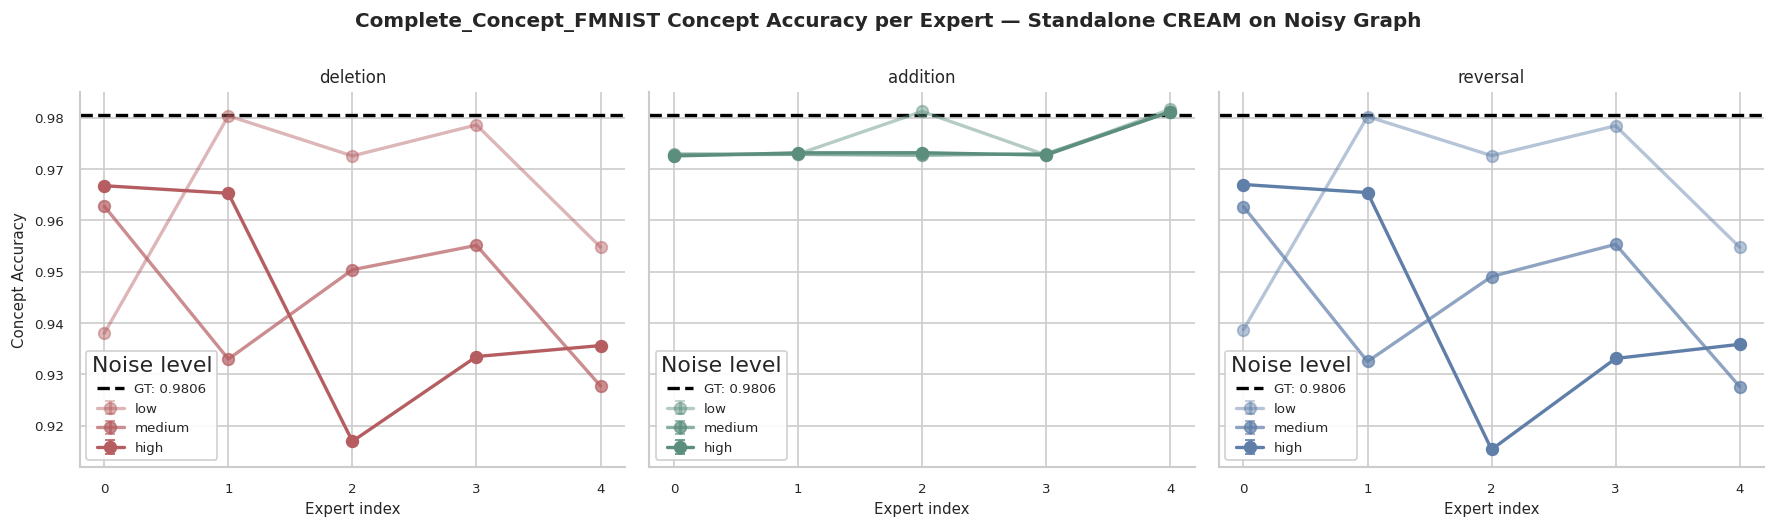

In [4]:
if len(noisy_df)==0: print('No data')
else:
    for ds in DATASETS:
        d = noisy_df[noisy_df['dataset']==ds]
        if d.empty: continue

        for metric, ylabel in [('test_task_accuracy',    'Task Accuracy'),
                                ('test_concept_accuracy', 'Concept Accuracy')]:
            if metric not in d.columns: continue

            fig,axes = plt.subplots(1,len(ACTIONS),figsize=(5*len(ACTIONS),4.5),sharey=True)
            fig.suptitle(f'{ds} {ylabel} per Expert — Standalone CREAM on Noisy Graph',
                         fontsize=12,fontweight='bold')

            # GT reference line
            gt_val = None
            if len(gt_df)>0 and metric in gt_df.columns:
                sub = gt_df[gt_df['dataset']==ds]
                if not sub.empty and pd.notna(sub[metric].mean()):
                    gt_val = sub[metric].mean()

            for ax,action in zip(axes,ACTIONS):
                act = d[d['action']==action]
                if act.empty: ax.set_title(action); continue
                for lv in LEVELS:
                    sub = act[act['noise_level']==lv]
                    if sub.empty: continue
                    agg = sub.groupby('expert')[metric].agg(['mean','std']).reset_index()
                    ax.errorbar(agg['expert'],agg['mean'],yerr=agg['std'],
                        label=lv,color=ACTION_COLOR[action],alpha=LEVEL_ALPHA[lv],
                        marker='o',markersize=7,linewidth=2,capsize=3)
                if gt_val is not None:
                    ax.axhline(gt_val,color='black',lw=2,ls='--',
                               label=f'GT: {gt_val:.4f}')
                ax.set_title(action,fontsize=10)
                ax.set_xlabel('Expert index',fontsize=9)
                ax.set_ylabel(ylabel if action==ACTIONS[0] else '',fontsize=9)
                ax.set_xticks(range(N_EXPERTS))
                ax.legend(title='Noise level',fontsize=8,framealpha=0.9)
                ax.tick_params(labelsize=8)
            plt.tight_layout()
            plt.savefig(f'cream_noisy_{metric}_{ds}.png',dpi=150,bbox_inches='tight')
            plt.show()


## 4. Robustness: Accuracy vs Noise Level


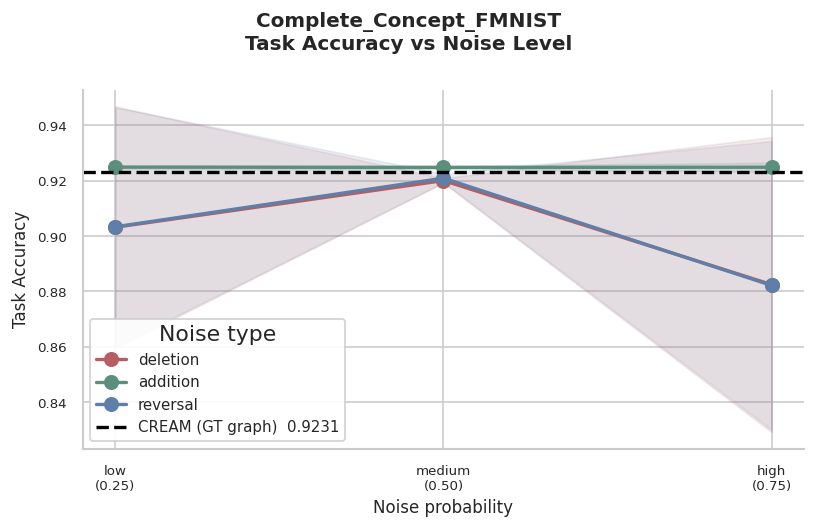

In [5]:
if len(noisy_df)==0: print('No data')
else:
    lnum = {'low':0.25,'medium':0.50,'high':0.75}
    for ds in DATASETS:
        d = noisy_df[noisy_df['dataset']==ds].copy()
        if d.empty: continue
        d['noise_prob'] = d['noise_level'].map(lnum)
        agg = d.groupby(['action','noise_prob'])['test_task_accuracy'].agg(['mean','std']).reset_index()
        fig,ax = plt.subplots(figsize=(7,4.5))
        fig.suptitle(f'{ds}\nTask Accuracy vs Noise Level',fontsize=12,fontweight='bold')
        for action in ACTIONS:
            sub = agg[agg['action']==action]
            if sub.empty: continue
            c = ACTION_COLOR[action]
            ax.plot(sub['noise_prob'],sub['mean'],color=c,marker='o',markersize=8,lw=2,label=action)
            ax.fill_between(sub['noise_prob'],sub['mean']-sub['std'],sub['mean']+sub['std'],alpha=0.12,color=c)
        if len(gt_df)>0 and 'test_task_accuracy' in gt_df.columns:
            sub = gt_df[gt_df['dataset']==ds]
            if not sub.empty:
                v = sub['test_task_accuracy'].mean()
                ax.axhline(v,color='black',lw=2,ls='--',label=f'CREAM (GT graph)  {v:.4f}')
        ax.set_xlabel('Noise probability',fontsize=10)
        ax.set_ylabel('Task Accuracy',fontsize=10)
        ax.set_xticks([0.25,0.50,0.75])
        ax.set_xticklabels(['low\n(0.25)','medium\n(0.50)','high\n(0.75)'])
        ax.legend(title='Noise type',fontsize=9,framealpha=0.9)
        ax.tick_params(labelsize=8)
        plt.tight_layout()
        plt.savefig(f'cream_noisy_robustness_{ds}.png',dpi=150,bbox_inches='tight')
        plt.show()


## 5. Intervention Curves


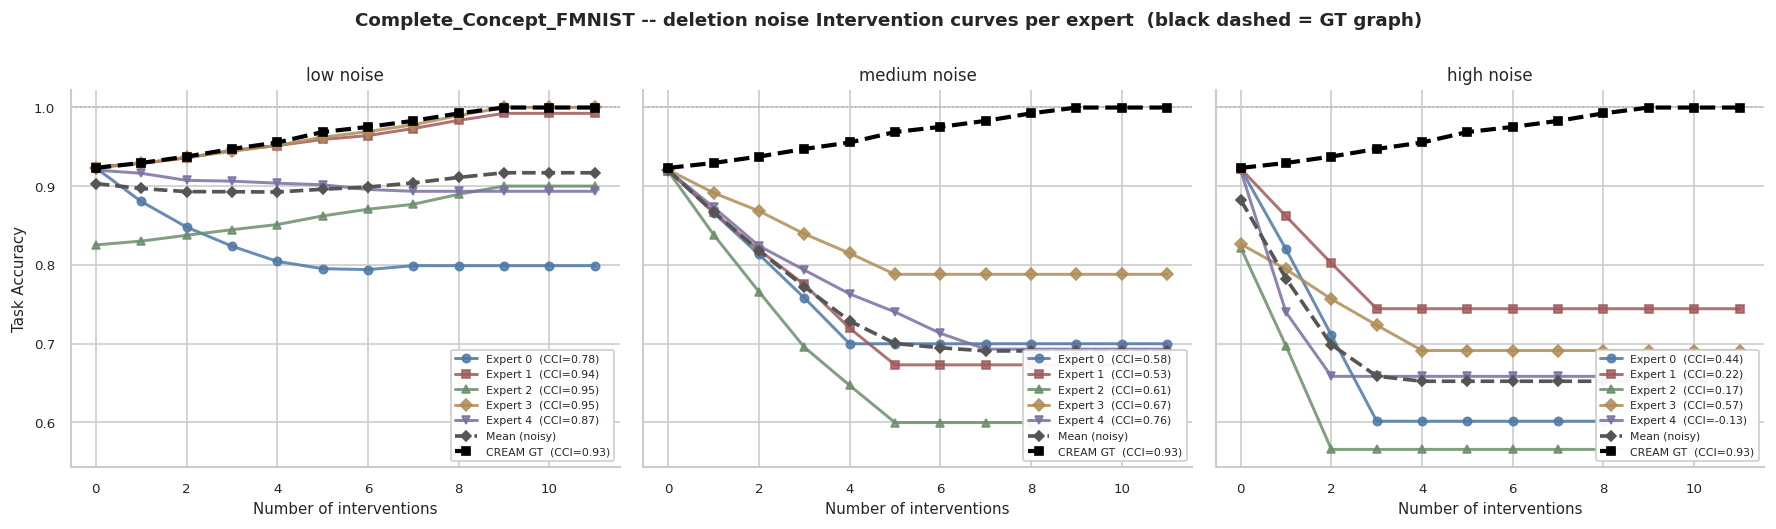

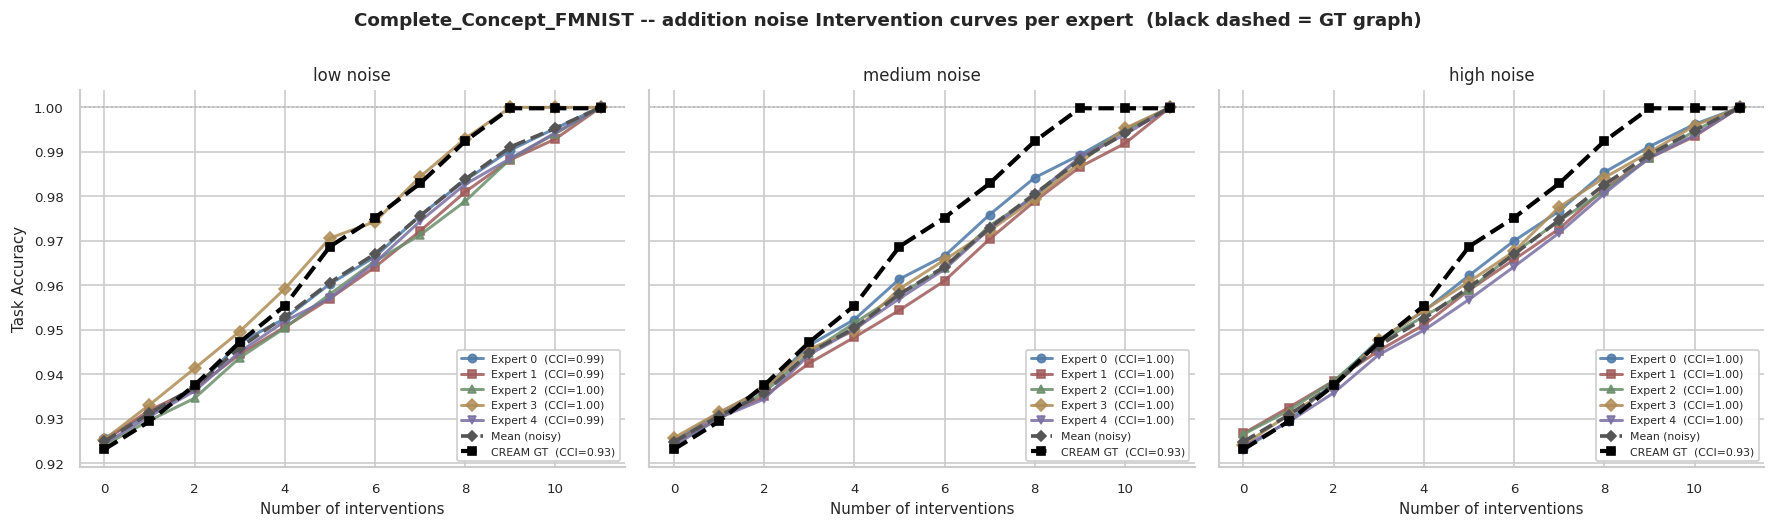

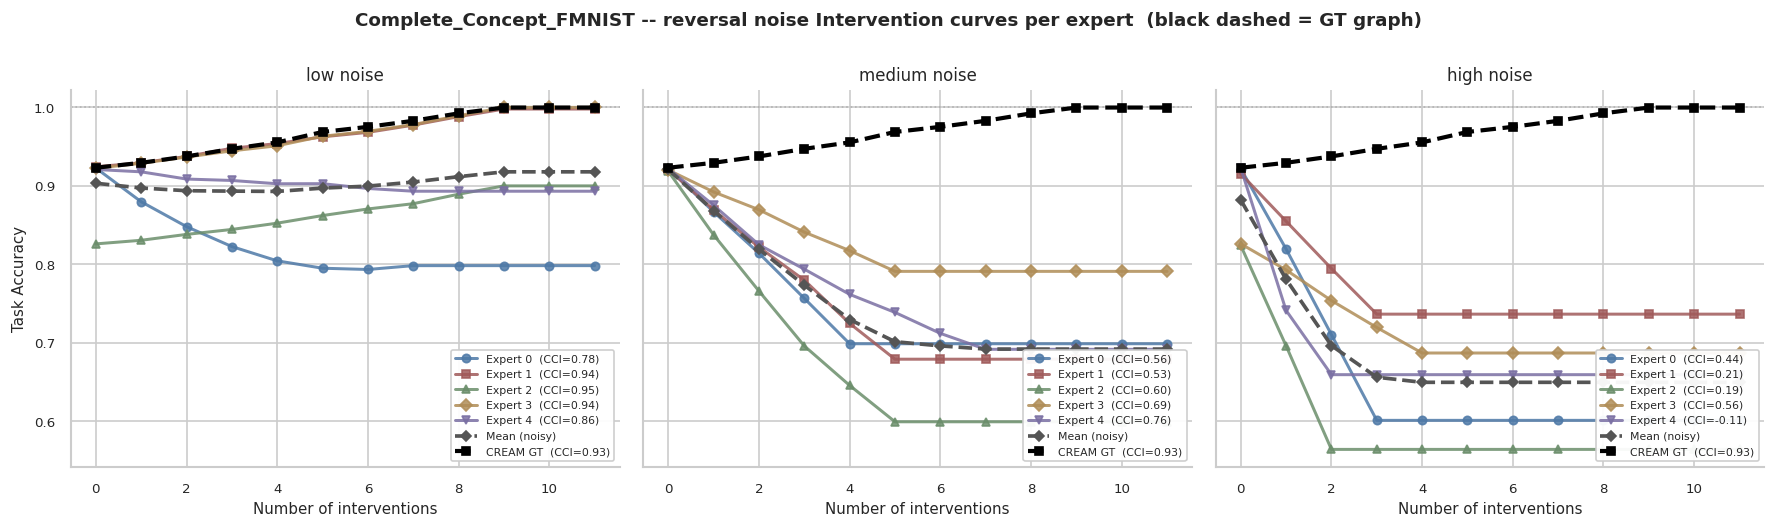

In [6]:
if len(interv_df)==0: print('No intervention data yet.')
else:
    for ds in DATASETS:
        for action in ACTIONS:
            sub = interv_df[
                (interv_df['dataset']==ds) &
                (interv_df['action']==action) &
                (~interv_df['group_interventions'])
            ]
            if sub.empty: continue
            fig,axes = plt.subplots(1,len(LEVELS),figsize=(5*len(LEVELS),4.5),sharey=True)
            fig.suptitle(f'{ds} -- {action} noise Intervention curves per expert  (black dashed = GT graph)',
                         fontsize=11,fontweight='bold')
            for ax,lv in zip(axes,LEVELS):
                lvs = sub[sub['noise_level']==lv]
                if lvs.empty: ax.set_title(f'{lv}'); continue
                for m in range(N_EXPERTS):
                    em = lvs[lvs['expert']==m]
                    if em.empty: continue
                    # Look up CCI for this expert from noisy_df
                    cci_m = None
                    if len(noisy_df)>0 and 'CCI' in noisy_df.columns:
                        cci_row = noisy_df[
                            (noisy_df['dataset']==ds) &
                            (noisy_df['action']==action) &
                            (noisy_df['noise_level']==lv) &
                            (noisy_df['expert']==m)
                        ]
                        if not cci_row.empty and pd.notna(cci_row['CCI'].mean()):
                            cci_m = cci_row['CCI'].mean()
                    label = f'Expert {m}  (CCI={cci_m:.2f})' if cci_m is not None else f'Expert {m}'
                    agg = em.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                    ax.plot(agg['num_interventions'],agg['mean'],
                        color=EXPERT_COLORS[m],marker=EXPERT_MARKERS[m],
                        markersize=5,lw=1.8,alpha=0.85,label=label)
                    ax.fill_between(agg['num_interventions'],agg['mean']-agg['std'],agg['mean']+agg['std'],
                        alpha=0.08,color=EXPERT_COLORS[m])
                mall = lvs.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
                ax.plot(mall['num_interventions'],mall['mean'],color='#555555',lw=2.2,ls='--',
                    marker='D',markersize=4,label='Mean (noisy)')
                if len(gt_interv)>0:
                    gts = gt_interv[(gt_interv['dataset']==ds)&(~gt_interv['group_interventions'])]
                    if not gts.empty:
                        gt_acc = gts['test_task_accuracy'].values
                        gt_ni  = gts['num_interventions'].values
                        # Add GT CCI from gt_df if available
                        gt_cci = None
                        if len(gt_df)>0 and 'CCI' in gt_df.columns:
                            sub2 = gt_df[gt_df['dataset']==ds]
                            if not sub2.empty and pd.notna(sub2['CCI'].mean()):
                                gt_cci = sub2['CCI'].mean()
                        gt_label = f'CREAM GT  (CCI={gt_cci:.2f})' if gt_cci is not None else 'CREAM (GT graph)'
                        ax.plot(gt_ni,gt_acc,color='black',lw=2.5,ls='--',
                            marker='s',markersize=5,label=gt_label,zorder=10)
                ax.axhline(1.0,color='gray',ls=':',alpha=0.4,lw=1)
                ax.set_title(f'{lv} noise',fontsize=10)
                ax.set_xlabel('Number of interventions',fontsize=9)
                ax.set_ylabel('Task Accuracy' if lv==LEVELS[0] else '',fontsize=9)
                ax.legend(fontsize=6.5,loc='lower right',framealpha=0.95)
                ax.tick_params(labelsize=8)
            plt.tight_layout()
            plt.savefig(f'cream_noisy_interventions_{ds}_{action}.png',dpi=150,bbox_inches='tight')
            plt.show()


## 6. CCI and PFI


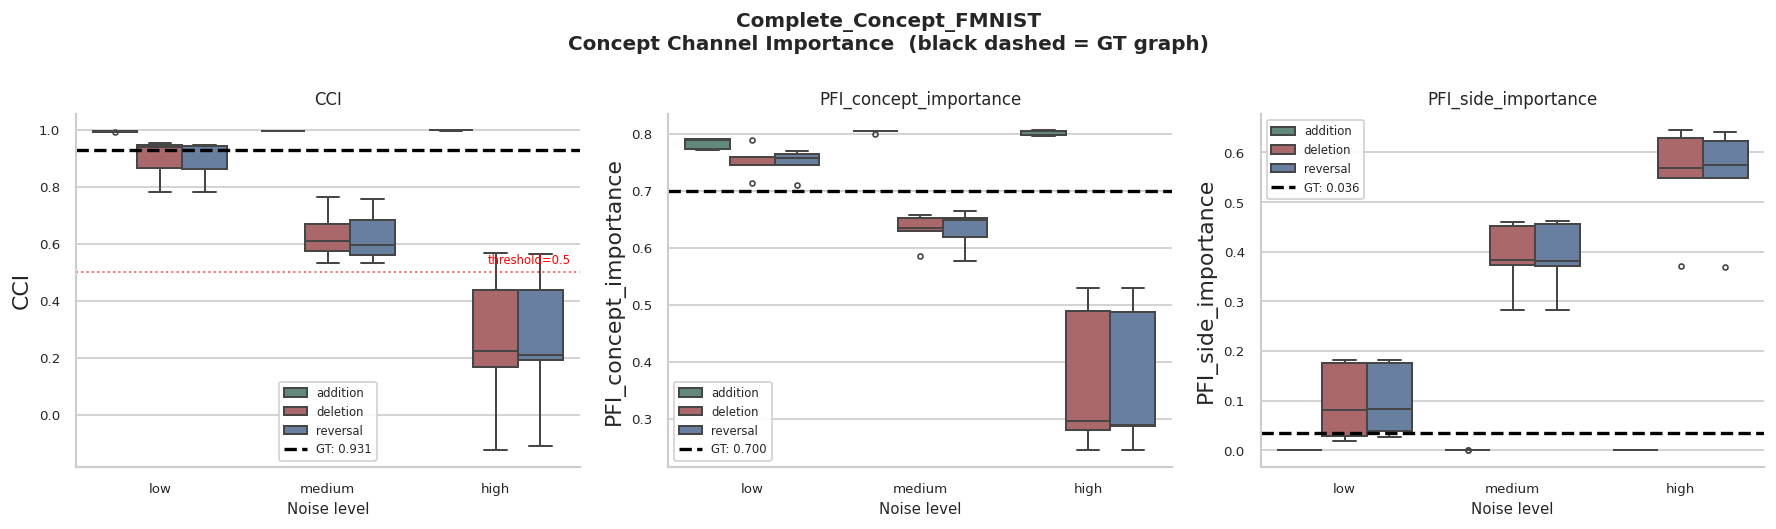

In [7]:
if len(noisy_df)==0: print('No data')
else:
    cc = [c for c in ['CCI','PFI_concept_importance','PFI_side_importance'] if c in noisy_df.columns]
    if not cc: print('CCI/PFI not found')
    else:
        for ds in DATASETS:
            d = noisy_df[noisy_df['dataset']==ds].dropna(subset=cc[:1])
            if d.empty: continue
            fig,axes = plt.subplots(1,len(cc),figsize=(5*len(cc),4.5))
            if len(cc)==1: axes=[axes]
            fig.suptitle(f'{ds}\nConcept Channel Importance  (black dashed = GT graph)',
                         fontsize=12,fontweight='bold')
            for ax,m in zip(axes,cc):
                sub = d.dropna(subset=[m])
                if sub.empty: continue
                sns.boxplot(data=sub,x='noise_level',y=m,hue='action',order=LEVELS,ax=ax,
                    palette=ACTION_COLOR,linewidth=1.2,fliersize=3)
                ax.set_title(m,fontsize=10)
                ax.set_xlabel('Noise level',fontsize=9)
                ax.legend(title='Action',fontsize=8,framealpha=0.9)
                ax.tick_params(labelsize=8)
                if len(gt_df)>0 and m in gt_df.columns:
                    sub2 = gt_df[gt_df['dataset']==ds]
                    if not sub2.empty:
                        v = sub2[m].mean()
                        if pd.notna(v):
                            ax.axhline(v,color='black',lw=2,ls='--',label=f'GT: {v:.3f}')
                            h,l = ax.get_legend_handles_labels()
                            ax.legend(h,l,fontsize=7,framealpha=0.9)
                if m=='CCI':
                    ax.axhline(0.5,color='red',lw=1.2,ls=':',alpha=0.6)
                    ax.text(ax.get_xlim()[1]*0.98,0.52,'threshold=0.5',
                        ha='right',va='bottom',fontsize=7,color='red')
            plt.tight_layout()
            plt.savefig(f'cream_noisy_cci_{ds}.png',dpi=150,bbox_inches='tight')
            plt.show()


## 7. Export Summary


In [8]:
if len(noisy_df)>0:
    key  = ['test_task_accuracy','test_concept_accuracy','CCI','PFI_concept_importance']
    av   = [c for c in key if c in noisy_df.columns]
    agg  = noisy_df.groupby(['dataset','action','noise_level','expert'])[av].agg(['mean','std']).round(4)
    agg.to_csv('cream_noisy_ensemble_summary.csv')
    print('Saved: cream_noisy_ensemble_summary.csv')
    display(agg)


Saved: cream_noisy_ensemble_summary.csv


test_task_accuracy      \
                                                                  mean std   
dataset                 action   noise_level expert                          
Complete_Concept_FMNIST addition high        0                  0.9232 NaN   
                                             1                  0.9267 NaN   
                                             2                  0.9265 NaN   
                                             3                  0.9241 NaN   
                                             4                  0.9237 NaN   
                                 low         0                  0.9256 NaN   
                                             1                  0.9251 NaN   
                                             2                  0.9240 NaN   
                                             3                  0.9253 NaN   
                                             4                  0.9244 NaN   
                                 medium      0                  0.9250 NaN   
                                             1                  0.9248 NaN   
                                             2                  0.9245 NaN   
                                             3                  0.9257 NaN   
                                             4                  0.9239 NaN   
                        deletion high        0                  0.9220 NaN   
                                             1                  0.9222 NaN   
                                             2                  0.8219 NaN   
                                             3                  0.8264 NaN   
                                             4                  0.9199 NaN   
                                 low         0                  0.9231 NaN   
                                             1                  0.9243 NaN   
                                             2                  0.8253 NaN   
                                             3                  0.9229 NaN   
                                             4                  0.9203 NaN   
                                 medium      0                  0.9211 NaN   
                                             1                  0.9197 NaN   
                                             2                  0.9190 NaN   
                                             3                  0.9206 NaN   
                                             4                  0.9197 NaN   
                        reversal high        0                  0.9220 NaN   
                                             1                  0.9155 NaN   
                                             2                  0.8241 NaN   
                                             3                  0.8262 NaN   
                                             4                  0.9230 NaN   
                                 low         0                  0.9228 NaN   
                                             1                  0.9244 NaN   
                                             2                  0.8261 NaN   
                                             3                  0.9225 NaN   
                                             4                  0.9209 NaN   
                                 medium      0                  0.9224 NaN   
                                             1                  0.9211 NaN   
                                             2                  0.9186 NaN   
                                             3                  0.9203 NaN   
                                             4                  0.9221 NaN   

                                                    test_concept_accuracy      \
                                                                     mean std   
dataset                 action   noise_level expert                             
Complete_Concept_FMNIST addition high        0                  

## 8. No-Side-Channel Comparison

Same experiments with `num_side_channel=0` — concepts only, no black-box bypass.

Left plot = with side channel, Right plot = no side channel — directly comparable.


In [ ]:
def load_noisy_no_side(root):
    rows = []
    for ds in DATASETS:
        model = MODEL_MAP[ds][0]
        md = root/ds/'train_cbm'/model/'cream_noisy_ensemble_no_side'/'last_metrics'
        if not md.exists(): print(f'  [SKIP] {md}'); continue
        for f in sorted(md.glob('cream_noisy_*.csv')):
            p = f.stem.split('_')
            try: act=p[2]; lv=p[3]; ex=int(p[4].replace('expert',''))
            except: continue
            df = pd.read_csv(f)
            df['dataset']=ds; df['action']=act; df['noise_level']=lv; df['expert']=ex
            rows.append(df)
    if not rows: print('No no-side results found'); return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)

def load_gt_no_side(root):
    ns_map = {
        'Complete_Concept_FMNIST': ('Standard_FashionMNIST','CREAM_no_side_best_cfmnist'),
        'CelebA': ('Standard_CelebA','CREAM_no_side_best_celeba'),
    }
    rows = []
    for ds,(model,exp) in ns_map.items():
        md = root/ds/'train_cbm'/model/exp/'last_metrics'
        if not md.exists(): print(f'  [SKIP] GT no-side: {md}'); continue
        for f in sorted(md.glob('*.csv')):
            df = pd.read_csv(f); df['dataset']=ds; rows.append(df)
    gt_ns = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if len(gt_ns)>0:
        for d in gt_ns['dataset'].unique():
            r = gt_ns[gt_ns['dataset']==d].iloc[0]
            print(f'  GT no-side {d}: acc={r.get("test_task_accuracy",float("nan")):.4f}')
    return gt_ns

noisy_ns_df = load_noisy_no_side(EXPERIMENTS_ROOT)
gt_ns_df    = load_gt_no_side(EXPERIMENTS_ROOT)
print(f'Loaded no-side noisy: {len(noisy_ns_df)} rows')


In [ ]:
lnum = {'low':0.25,'medium':0.50,'high':0.75}
if len(noisy_ns_df)==0: print('No no-side data yet.')
else:
    for ds in DATASETS:
        for metric, ylabel in [('test_task_accuracy','Task Accuracy'),
                                ('test_concept_accuracy','Concept Accuracy')]:
            has_side = len(noisy_df)>0 and metric in noisy_df.columns
            has_ns   = metric in noisy_ns_df.columns
            if not has_ns: continue
            fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
            fig.suptitle(f'{ds} — {ylabel} vs Noise Level\n'
                         f'Left: with side channel  |  Right: no side channel',
                         fontsize=11, fontweight='bold')
            for ax, df_src, gt_src, title in [
                (axes[0], noisy_df[noisy_df['dataset']==ds].copy() if has_side else pd.DataFrame(), gt_df, 'With side channel'),
                (axes[1], noisy_ns_df[noisy_ns_df['dataset']==ds].copy(), gt_ns_df, 'No side channel'),
            ]:
                if df_src.empty: ax.set_title(f'{title} — no data'); continue
                df_src = df_src.copy()
                df_src['noise_prob'] = df_src['noise_level'].map(lnum)
                agg = df_src.groupby(['action','noise_prob'])[metric].agg(['mean','std']).reset_index()
                for action in ACTIONS:
                    sub = agg[agg['action']==action]
                    if sub.empty: continue
                    c = ACTION_COLOR[action]
                    ax.plot(sub['noise_prob'],sub['mean'],color=c,marker='o',markersize=7,lw=2,label=action)
                    ax.fill_between(sub['noise_prob'],sub['mean']-sub['std'],sub['mean']+sub['std'],alpha=0.12,color=c)
                if len(gt_src)>0 and metric in gt_src.columns:
                    sub2 = gt_src[gt_src['dataset']==ds]
                    if not sub2.empty and pd.notna(sub2[metric].mean()):
                        v = sub2[metric].mean()
                        ax.axhline(v,color='black',lw=2,ls='--',label=f'CREAM GT: {v:.4f}')
                ax.set_title(title,fontsize=10)
                ax.set_xlabel('Noise probability',fontsize=9)
                ax.set_ylabel(ylabel if ax is axes[0] else '',fontsize=9)
                ax.set_xticks([0.25,0.50,0.75])
                ax.set_xticklabels(['low','medium','high'])
                ax.legend(title='Noise type',fontsize=8,framealpha=0.9)
                ax.tick_params(labelsize=8)
            plt.tight_layout()
            plt.savefig(f'cream_noisy_no_side_comparison_{metric}_{ds}.png',dpi=150,bbox_inches='tight')
            plt.show()
